# HW10-11: Компьютерное зрение в PyTorch

**Часть A (S10):** Классификация изображений — STL10, CNN с нуля, аугментации, transfer learning (ResNet18).  
**Часть B (S11):** Семантическая сегментация — OxfordIIITPet, DeepLabV3, два режима постобработки.

> Запускать последовательно (Run All). Все пути относительные.  
> В Google Colab: клонируйте репозиторий и выполните `%cd` в директорию `homeworks/HW10-11` перед запуском.

In [1]:
import os
import math
import time
import random
import json
from typing import Dict, List, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

import pandas as pd

DATA_DIR = './data'
ARTIFACTS_DIR = './artifacts'
FIGURES_DIR = './artifacts/figures'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)

torch: 2.10.0+cu128
torchvision: 0.25.0+cu128


In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

FAST_MODE = False
BATCH_SIZE = 64
EPOCHS_CNN = 3 if FAST_MODE else 15
EPOCHS_RN  = 3 if FAST_MODE else 10
NUM_CLASSES = 10

Device: cuda


---
## Часть A: Классификация изображений (STL10)

Датасет STL10: 10 классов, 96×96 RGB.  
Train: 5000, Test: 8000. Разбиваем train на train/val 80/20.

Эксперименты:
- **C1** — SimpleCNN, без аугментаций
- **C2** — SimpleCNN, с аугментациями
- **C3** — ResNet18 pretrained, head-only
- **C4** — ResNet18 pretrained, fine-tune (layer4 + fc)

### A.1 Transforms

In [3]:
STL10_MEAN = (0.4467, 0.4398, 0.4066)
STL10_STD  = (0.2603, 0.2566, 0.2713)

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# C1: базовый (без аугментаций)
base_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD),
])

# C2: с аугментациями
aug_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomCrop(96, padding=8),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD),
])

# C3/C4: ResNet transforms (224x224, ImageNet stats)
resnet_train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

resnet_eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

### A.2 Данные и DataLoader'ы

In [4]:
# Загружаем STL10 с разными transforms (один download, остальные из кеша)
ds_train_base     = torchvision.datasets.STL10(DATA_DIR, split='train', download=True,  transform=base_tf)
ds_train_aug      = torchvision.datasets.STL10(DATA_DIR, split='train', download=False, transform=aug_tf)
ds_train_rn_aug   = torchvision.datasets.STL10(DATA_DIR, split='train', download=False, transform=resnet_train_tf)
ds_train_rn_eval  = torchvision.datasets.STL10(DATA_DIR, split='train', download=False, transform=resnet_eval_tf)

ds_test_base = torchvision.datasets.STL10(DATA_DIR, split='test', download=False, transform=base_tf)
ds_test_rn   = torchvision.datasets.STL10(DATA_DIR, split='test', download=False, transform=resnet_eval_tf)

class_names = ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

# Train/val split: 80/20 по одинаковым индексам
n_total = len(ds_train_base)
n_val = int(n_total * 0.2)
rng = np.random.RandomState(RANDOM_STATE)
indices = np.arange(n_total)
rng.shuffle(indices)
val_idx = indices[:n_val].tolist()
train_idx = indices[n_val:].tolist()

# DataLoaders
loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)

train_loader_c1 = DataLoader(Subset(ds_train_base, train_idx),    shuffle=True,  **loader_kw)
train_loader_c2 = DataLoader(Subset(ds_train_aug, train_idx),     shuffle=True,  **loader_kw)
train_loader_rn = DataLoader(Subset(ds_train_rn_aug, train_idx),  shuffle=True,  **loader_kw)

val_loader_base = DataLoader(Subset(ds_train_base, val_idx),      shuffle=False, **loader_kw)
val_loader_rn   = DataLoader(Subset(ds_train_rn_eval, val_idx),   shuffle=False, **loader_kw)

test_loader_base = DataLoader(ds_test_base, shuffle=False, **loader_kw)
test_loader_rn   = DataLoader(ds_test_rn,   shuffle=False, **loader_kw)

print(f'Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(ds_test_base)}')
x, y = next(iter(train_loader_c1))
print('Batch shape:', x.shape, y.shape)

100%|██████████| 2.64G/2.64G [01:07<00:00, 38.9MB/s]


Train: 4000, Val: 1000, Test: 8000
Batch shape: torch.Size([64, 3, 96, 96]) torch.Size([64])


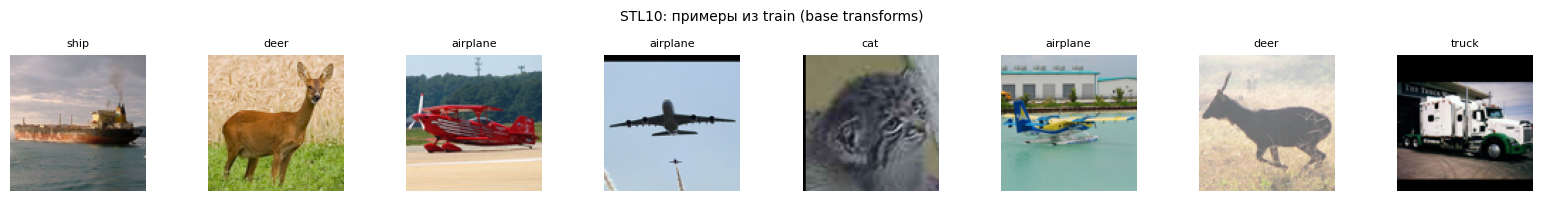

In [5]:
def denorm(x: torch.Tensor, mean, std) -> torch.Tensor:
    m = torch.tensor(mean).view(3, 1, 1)
    s = torch.tensor(std).view(3, 1, 1)
    return (x * s + m).clamp(0, 1)

x, y = next(iter(train_loader_c1))
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i in range(8):
    img = denorm(x[i].cpu(), STL10_MEAN, STL10_STD).permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].set_title(class_names[y[i]], fontsize=8)
    axes[i].axis('off')
plt.suptitle('STL10: примеры из train (base transforms)', fontsize=10)
plt.tight_layout()
plt.show()

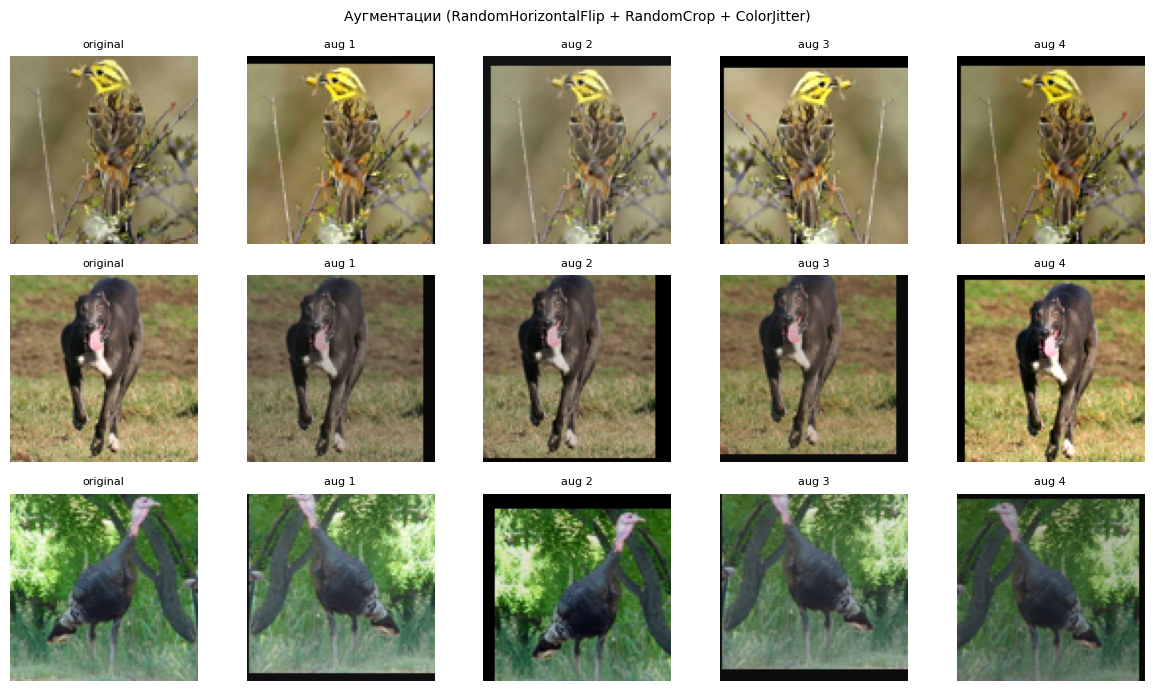

Saved augmentations_preview.png


In [6]:
# Визуализация аугментаций: оригинал + 4 варианта
ds_raw = torchvision.datasets.STL10(DATA_DIR, split='train', download=False, transform=None)

fig, axes = plt.subplots(3, 5, figsize=(12, 7))
for row in range(3):
    img_pil, _ = ds_raw[row]
    axes[row, 0].imshow(img_pil)
    axes[row, 0].set_title('original', fontsize=8)
    axes[row, 0].axis('off')
    for col in range(1, 5):
        aug_t = aug_tf(img_pil)
        img_vis = denorm(aug_t, STL10_MEAN, STL10_STD).permute(1, 2, 0).numpy()
        axes[row, col].imshow(img_vis)
        axes[row, col].set_title(f'aug {col}', fontsize=8)
        axes[row, col].axis('off')
plt.suptitle('Аугментации (RandomHorizontalFlip + RandomCrop + ColorJitter)', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'augmentations_preview.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved augmentations_preview.png')

### A.3 Модели

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),    # 96->48
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 48->24
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 24->12
        )
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Sanity check
tmp = SimpleCNN(NUM_CLASSES).to(DEVICE)
with torch.no_grad():
    out = tmp(torch.randn(2, 3, 96, 96).to(DEVICE))
print('SimpleCNN output:', out.shape)
print('SimpleCNN params:', count_params(tmp))
del tmp

SimpleCNN output: torch.Size([2, 10])
SimpleCNN params: 620362


In [8]:
def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

def build_resnet18_head_only(num_classes: int) -> nn.Module:
    model = resnet18(weights=ResNet18_Weights.DEFAULT)
    set_requires_grad(model, False)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def build_resnet18_finetune(num_classes: int) -> nn.Module:
    model = resnet18(weights=ResNet18_Weights.DEFAULT)
    set_requires_grad(model, False)
    set_requires_grad(model.layer4, True)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

# Sanity check
tmp_h = build_resnet18_head_only(NUM_CLASSES)
tmp_f = build_resnet18_finetune(NUM_CLASSES)
print('ResNet18 head-only trainable params:', count_params(tmp_h))
print('ResNet18 finetune trainable params:', count_params(tmp_f))
del tmp_h, tmp_f

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]


ResNet18 head-only trainable params: 5130
ResNet18 finetune trainable params: 8398858


### A.4 Цикл обучения

In [9]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        if not torch.isfinite(loss):
            return float('nan'), float('nan')
        loss.backward()
        optimizer.step()
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (logits.argmax(1) == y).sum().item()
        total_seen += bs
    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)
        if not torch.isfinite(loss):
            return float('nan'), float('nan')
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (logits.argmax(1) == y).sum().item()
        total_seen += bs
    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int,
        verbose: bool = True):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_state = None
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        dt = time.time() - t0
        if verbose:
            print(f'Epoch {epoch:02d}/{epochs} | '
                  f'train loss {tr_loss:.4f} acc {tr_acc:.3f} | '
                  f'val loss {va_loss:.4f} acc {va_acc:.3f} | {dt:.1f}s')
        if not math.isfinite(tr_loss):
            print('NaN/Inf detected, stopping.')
            break
    return history, best_val_acc, best_state

def plot_history(hist, title=''):
    epochs = range(1, len(hist['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs, hist['train_loss'], label='train')
    ax1.plot(epochs, hist['val_loss'], label='val')
    ax1.set_xlabel('epoch'); ax1.set_ylabel('loss')
    ax1.set_title(f'{title} | loss'); ax1.legend(); ax1.grid(True)
    ax2.plot(epochs, hist['train_acc'], label='train')
    ax2.plot(epochs, hist['val_acc'], label='val')
    ax2.set_xlabel('epoch'); ax2.set_ylabel('accuracy')
    ax2.set_title(f'{title} | accuracy'); ax2.legend(); ax2.grid(True)
    plt.tight_layout()
    return fig

@torch.no_grad()
def accuracy_on_loader(model, loader) -> float:
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        correct += (model(x).argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total

criterion = nn.CrossEntropyLoss()
all_results = {}  # exp_id -> dict

### A.5 Эксперименты C1–C4

#### C1: SimpleCNN — без аугментаций

C1: SimpleCNN, params=620362, epochs=15
Epoch 01/15 | train loss 1.9354 acc 0.264 | val loss 1.6799 acc 0.379 | 3.6s
Epoch 02/15 | train loss 1.5698 acc 0.405 | val loss 1.5647 acc 0.417 | 3.9s
Epoch 03/15 | train loss 1.4073 acc 0.475 | val loss 1.4107 acc 0.472 | 3.6s
Epoch 04/15 | train loss 1.2778 acc 0.525 | val loss 1.3883 acc 0.495 | 3.1s
Epoch 05/15 | train loss 1.1865 acc 0.567 | val loss 1.3492 acc 0.498 | 3.1s
Epoch 06/15 | train loss 1.0727 acc 0.603 | val loss 1.3684 acc 0.497 | 4.3s
Epoch 07/15 | train loss 1.0084 acc 0.636 | val loss 1.2955 acc 0.540 | 3.1s
Epoch 08/15 | train loss 0.9396 acc 0.655 | val loss 1.2173 acc 0.578 | 3.1s
Epoch 09/15 | train loss 0.8254 acc 0.695 | val loss 1.2459 acc 0.588 | 3.1s
Epoch 10/15 | train loss 0.7537 acc 0.725 | val loss 1.2458 acc 0.586 | 4.4s
Epoch 11/15 | train loss 0.6809 acc 0.748 | val loss 1.2897 acc 0.582 | 3.2s
Epoch 12/15 | train loss 0.5959 acc 0.792 | val loss 1.3590 acc 0.576 | 3.3s
Epoch 13/15 | train loss 0.5169 acc 

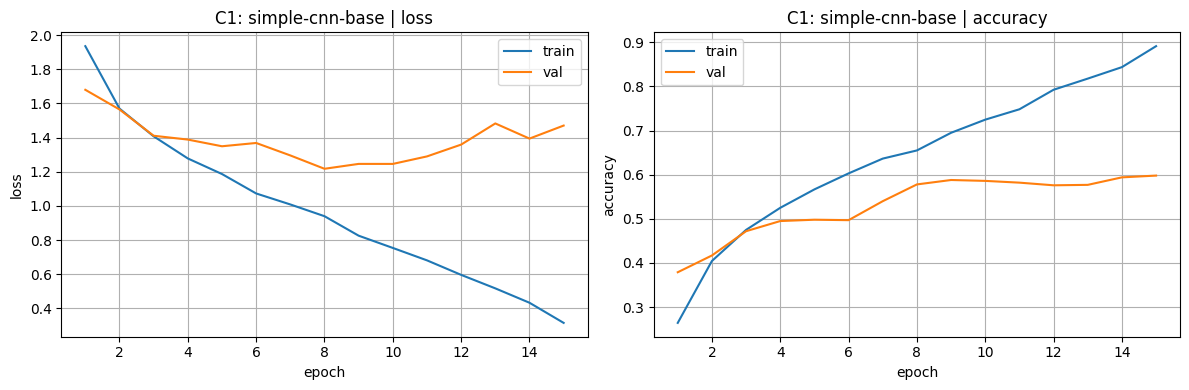

C1 best val acc: 0.5980


In [10]:
set_seed(RANDOM_STATE)
model_c1 = SimpleCNN(NUM_CLASSES).to(DEVICE)
opt_c1 = torch.optim.Adam(model_c1.parameters(), lr=1e-3)
print(f'C1: SimpleCNN, params={count_params(model_c1)}, epochs={EPOCHS_CNN}')

hist_c1, best_c1, state_c1 = fit(model_c1, train_loader_c1, val_loader_base,
                                  opt_c1, criterion, EPOCHS_CNN)
fig = plot_history(hist_c1, 'C1: simple-cnn-base')
plt.show()

all_results['C1'] = {
    'name': 'simple-cnn-base', 'best_val_acc': best_c1,
    'history': hist_c1, 'state': state_c1,
    'loader_type': 'base', 'params': count_params(model_c1),
}
print(f'C1 best val acc: {best_c1:.4f}')

#### C2: SimpleCNN — с аугментациями

C2: SimpleCNN + aug, params=620362, epochs=15
Epoch 01/15 | train loss 2.0159 acc 0.236 | val loss 1.7534 acc 0.370 | 5.9s
Epoch 02/15 | train loss 1.6628 acc 0.373 | val loss 1.5510 acc 0.404 | 6.3s
Epoch 03/15 | train loss 1.5287 acc 0.424 | val loss 1.5205 acc 0.451 | 5.7s
Epoch 04/15 | train loss 1.4459 acc 0.460 | val loss 1.3534 acc 0.498 | 6.7s
Epoch 05/15 | train loss 1.3570 acc 0.494 | val loss 1.3323 acc 0.507 | 5.5s
Epoch 06/15 | train loss 1.2723 acc 0.534 | val loss 1.4156 acc 0.485 | 6.7s
Epoch 07/15 | train loss 1.2454 acc 0.537 | val loss 1.2138 acc 0.555 | 5.6s
Epoch 08/15 | train loss 1.1760 acc 0.569 | val loss 1.2108 acc 0.555 | 6.8s
Epoch 09/15 | train loss 1.1368 acc 0.584 | val loss 1.1842 acc 0.575 | 5.4s
Epoch 10/15 | train loss 1.0945 acc 0.603 | val loss 1.1639 acc 0.580 | 6.7s
Epoch 11/15 | train loss 1.0640 acc 0.615 | val loss 1.1262 acc 0.594 | 5.5s
Epoch 12/15 | train loss 1.0123 acc 0.626 | val loss 1.1007 acc 0.605 | 6.7s
Epoch 13/15 | train loss 0.995

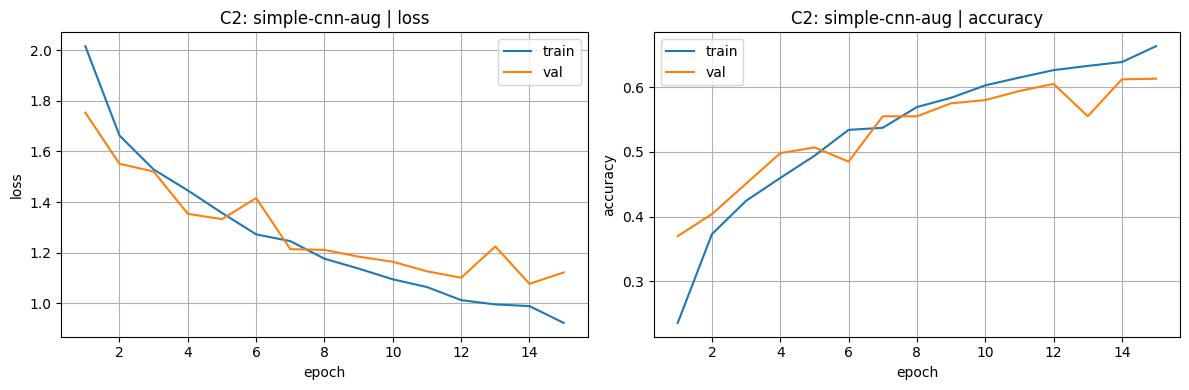

C2 best val acc: 0.6130


In [11]:
set_seed(RANDOM_STATE)
model_c2 = SimpleCNN(NUM_CLASSES).to(DEVICE)
opt_c2 = torch.optim.Adam(model_c2.parameters(), lr=1e-3)
print(f'C2: SimpleCNN + aug, params={count_params(model_c2)}, epochs={EPOCHS_CNN}')

hist_c2, best_c2, state_c2 = fit(model_c2, train_loader_c2, val_loader_base,
                                  opt_c2, criterion, EPOCHS_CNN)
fig = plot_history(hist_c2, 'C2: simple-cnn-aug')
plt.show()

all_results['C2'] = {
    'name': 'simple-cnn-aug', 'best_val_acc': best_c2,
    'history': hist_c2, 'state': state_c2,
    'loader_type': 'base', 'params': count_params(model_c2),
}
print(f'C2 best val acc: {best_c2:.4f}')

#### C3: ResNet18 — head-only

C3: ResNet18 head-only, trainable params=5130, epochs=10
Epoch 01/10 | train loss 1.0516 acc 0.743 | val loss 0.4619 acc 0.892 | 16.5s
Epoch 02/10 | train loss 0.3871 acc 0.914 | val loss 0.3080 acc 0.909 | 16.8s
Epoch 03/10 | train loss 0.2904 acc 0.925 | val loss 0.2550 acc 0.923 | 16.7s
Epoch 04/10 | train loss 0.2466 acc 0.935 | val loss 0.2298 acc 0.925 | 16.1s
Epoch 05/10 | train loss 0.2187 acc 0.940 | val loss 0.2127 acc 0.932 | 16.0s
Epoch 06/10 | train loss 0.2071 acc 0.939 | val loss 0.2100 acc 0.933 | 16.2s
Epoch 07/10 | train loss 0.1892 acc 0.947 | val loss 0.1938 acc 0.937 | 17.0s
Epoch 08/10 | train loss 0.1825 acc 0.943 | val loss 0.1904 acc 0.941 | 15.8s
Epoch 09/10 | train loss 0.1699 acc 0.948 | val loss 0.1959 acc 0.942 | 15.6s
Epoch 10/10 | train loss 0.1688 acc 0.949 | val loss 0.1812 acc 0.936 | 15.5s


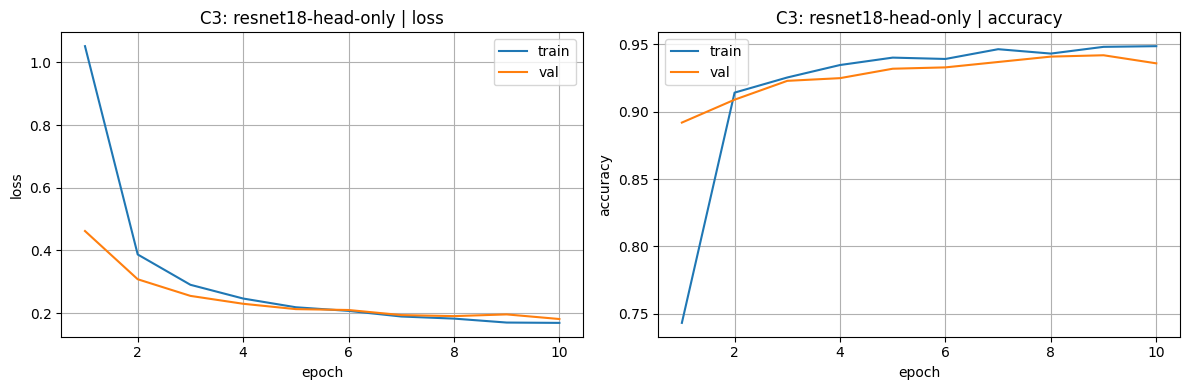

C3 best val acc: 0.9420


In [12]:
set_seed(RANDOM_STATE)
model_c3 = build_resnet18_head_only(NUM_CLASSES).to(DEVICE)
opt_c3 = torch.optim.Adam(model_c3.fc.parameters(), lr=1e-3)
print(f'C3: ResNet18 head-only, trainable params={count_params(model_c3)}, epochs={EPOCHS_RN}')

hist_c3, best_c3, state_c3 = fit(model_c3, train_loader_rn, val_loader_rn,
                                  opt_c3, criterion, EPOCHS_RN)
fig = plot_history(hist_c3, 'C3: resnet18-head-only')
plt.show()

all_results['C3'] = {
    'name': 'resnet18-head-only', 'best_val_acc': best_c3,
    'history': hist_c3, 'state': state_c3,
    'loader_type': 'rn', 'params': count_params(model_c3),
}
print(f'C3 best val acc: {best_c3:.4f}')

#### C4: ResNet18 — fine-tune (layer4 + fc)

C4: ResNet18 finetune, trainable params=8398858, epochs=10
Epoch 01/10 | train loss 0.4944 acc 0.861 | val loss 0.1801 acc 0.941 | 16.1s
Epoch 02/10 | train loss 0.1356 acc 0.961 | val loss 0.1657 acc 0.946 | 17.2s
Epoch 03/10 | train loss 0.0790 acc 0.977 | val loss 0.1572 acc 0.948 | 15.9s
Epoch 04/10 | train loss 0.0503 acc 0.988 | val loss 0.1457 acc 0.946 | 15.6s
Epoch 05/10 | train loss 0.0261 acc 0.996 | val loss 0.1582 acc 0.942 | 16.2s
Epoch 06/10 | train loss 0.0236 acc 0.995 | val loss 0.1646 acc 0.945 | 16.6s
Epoch 07/10 | train loss 0.0213 acc 0.994 | val loss 0.1629 acc 0.943 | 16.0s
Epoch 08/10 | train loss 0.0176 acc 0.996 | val loss 0.1751 acc 0.946 | 15.9s
Epoch 09/10 | train loss 0.0212 acc 0.994 | val loss 0.2062 acc 0.944 | 16.2s
Epoch 10/10 | train loss 0.0144 acc 0.996 | val loss 0.2296 acc 0.939 | 16.2s


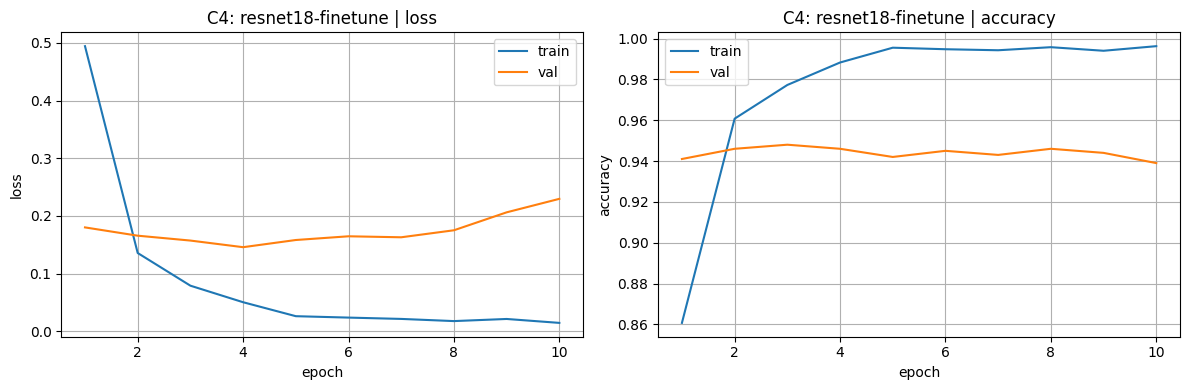

C4 best val acc: 0.9480


In [13]:
set_seed(RANDOM_STATE)
model_c4 = build_resnet18_finetune(NUM_CLASSES).to(DEVICE)
opt_c4 = torch.optim.Adam([
    {'params': model_c4.layer4.parameters(), 'lr': 1e-4},
    {'params': model_c4.fc.parameters(), 'lr': 1e-3},
], weight_decay=1e-4)
print(f'C4: ResNet18 finetune, trainable params={count_params(model_c4)}, epochs={EPOCHS_RN}')

hist_c4, best_c4, state_c4 = fit(model_c4, train_loader_rn, val_loader_rn,
                                  opt_c4, criterion, EPOCHS_RN)
fig = plot_history(hist_c4, 'C4: resnet18-finetune')
plt.show()

all_results['C4'] = {
    'name': 'resnet18-finetune', 'best_val_acc': best_c4,
    'history': hist_c4, 'state': state_c4,
    'loader_type': 'rn', 'params': count_params(model_c4),
}
print(f'C4 best val acc: {best_c4:.4f}')

### A.6 Сравнение C1–C4 и выбор лучшей модели

exp_id               name  params  best_val_acc
    C1    simple-cnn-base  620362         0.598
    C2     simple-cnn-aug  620362         0.613
    C3 resnet18-head-only    5130         0.942
    C4  resnet18-finetune 8398858         0.948


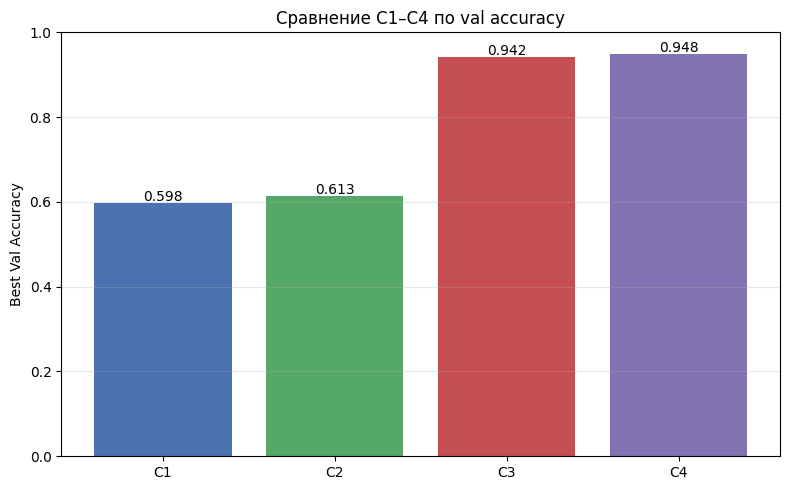

Saved classification_compare.png


In [14]:
# Сводная таблица
summary = []
for exp_id in ['C1', 'C2', 'C3', 'C4']:
    r = all_results[exp_id]
    summary.append({'exp_id': exp_id, 'name': r['name'],
                    'params': r['params'], 'best_val_acc': r['best_val_acc']})
df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False))

# Bar plot
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b2']
bars = ax.bar(df_summary['exp_id'], df_summary['best_val_acc'], color=colors)
for bar, val in zip(bars, df_summary['best_val_acc']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=10)
ax.set_ylabel('Best Val Accuracy')
ax.set_title('Сравнение C1–C4 по val accuracy')
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'classification_compare.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved classification_compare.png')

Лучший эксперимент: C4 (resnet18-finetune), val_acc=0.9480


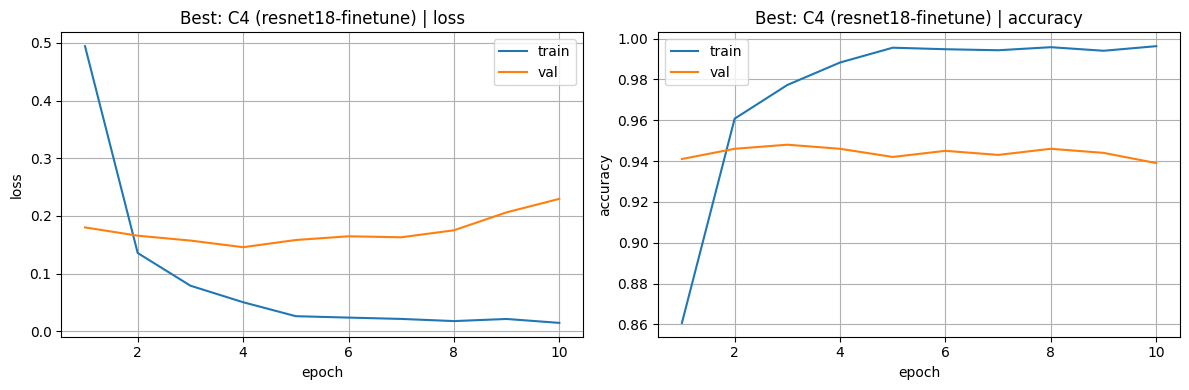

Saved classification_curves_best.png


In [15]:
# Выбор лучшей модели по val accuracy
best_exp = max(all_results, key=lambda k: all_results[k]['best_val_acc'])
best_info = all_results[best_exp]
print(f'Лучший эксперимент: {best_exp} ({best_info["name"]}), val_acc={best_info["best_val_acc"]:.4f}')

# Кривые лучшего прогона
fig = plot_history(best_info['history'], f'Best: {best_exp} ({best_info["name"]})')
plt.savefig(os.path.join(FIGURES_DIR, 'classification_curves_best.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved classification_curves_best.png')

In [16]:
# Финальная оценка на test (один раз)
if best_info['loader_type'] == 'rn':
    # Восстанавливаем модель ResNet
    if best_exp == 'C3':
        best_model = build_resnet18_head_only(NUM_CLASSES).to(DEVICE)
    else:
        best_model = build_resnet18_finetune(NUM_CLASSES).to(DEVICE)
    best_model.load_state_dict(best_info['state'])
    test_acc = accuracy_on_loader(best_model, test_loader_rn)
else:
    best_model = SimpleCNN(NUM_CLASSES).to(DEVICE)
    best_model.load_state_dict(best_info['state'])
    test_acc = accuracy_on_loader(best_model, test_loader_base)

print(f'Test accuracy ({best_exp}): {test_acc:.4f}')
all_results[best_exp]['test_acc'] = test_acc

Test accuracy (C4): 0.9449


In [17]:
# Сохраняем лучший классификатор
torch.save(best_info["state"], os.path.join(ARTIFACTS_DIR, "best_classifier.pt"))

config = {
    "experiment": best_exp,
    "name": best_info["name"],
    "dataset": "STL10",
    "num_classes": NUM_CLASSES,
    "seed": RANDOM_STATE,
    "batch_size": BATCH_SIZE,
    "optimizer": "Adam",
    "best_val_accuracy": best_info["best_val_acc"],
    "test_accuracy": test_acc,
    "trainable_params": best_info["params"],
    "architecture": {
        "base_model": "ResNet18" if "resnet" in best_info["name"] else "SimpleCNN",
        "weights": "ResNet18_Weights.IMAGENET1K_V1" if "resnet" in best_info["name"] else "from scratch",
        "trainable_layers": "layer4 + fc" if "finetune" in best_info["name"] else ("fc only" if "head" in best_info["name"] else "all"),
    },
    "transforms": {
        "train": ["Resize(256)", "RandomResizedCrop(224, scale=(0.7,1.0))", "RandomHorizontalFlip(0.5)", "ToTensor()", "Normalize(ImageNet)"] if best_info["loader_type"] == "rn" else ["ToTensor()", "Normalize(STL10)"],
        "val_test": ["Resize(256)", "CenterCrop(224)", "ToTensor()", "Normalize(ImageNet)"] if best_info["loader_type"] == "rn" else ["ToTensor()", "Normalize(STL10)"],
    },
}
with open(os.path.join(ARTIFACTS_DIR, "best_classifier_config.json"), "w") as f:
    json.dump(config, f, indent=2)

print("Saved best_classifier.pt and best_classifier_config.json")
print(json.dumps(config, indent=2))

Saved best_classifier.pt and best_classifier_config.json
{
  "experiment": "C4",
  "name": "resnet18-finetune",
  "dataset": "STL10",
  "num_classes": 10,
  "seed": 42,
  "batch_size": 64,
  "optimizer": "Adam",
  "best_val_accuracy": 0.948,
  "test_accuracy": 0.944875,
  "trainable_params": 8398858
}


---
## Часть B: Семантическая сегментация (OxfordIIITPet)

Датасет OxfordIIITPet: изображения кошек/собак + тримап-маски (1 = питомец, 2 = фон, 3 = граница).  
Модель: DeepLabV3_ResNet50 (COCO_WITH_VOC_LABELS_V1), только инференс (без дообучения).  

**Foreground-класс (ground truth):** `trimap == 1` — пиксели, принадлежащие питомцу (кошка или собака).  
**Foreground-класс (prediction):** пиксели, где argmax модели = `cat` (COCO-VOC idx 8) **или** `dog` (COCO-VOC idx 12).  
Остальные классы (фон, мебель, люди и т.д.) считаются background.

- **V1** — базовая постобработка (argmax → бинарная маска cat|dog)
- **V2** — удаление малых связных компонент (< 500 пикселей) через `skimage.morphology.remove_small_objects`

### B.1 Датасет OxfordIIITPet

100%|██████████| 792M/792M [00:36<00:00, 21.8MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.7MB/s]


OxfordIIITPet: 3680 images
Image size: (394, 500), Trimap shape: (500, 394)
Trimap unique values: [1 2 3]


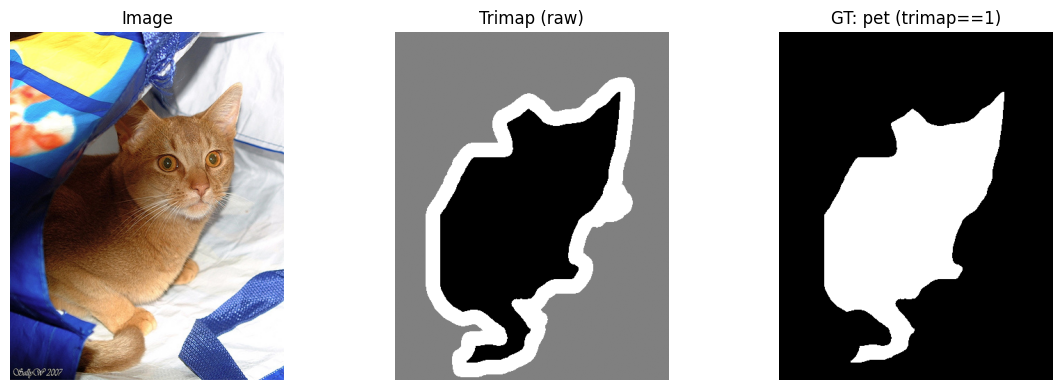

In [18]:
from torchvision.datasets import OxfordIIITPet

ds_pet = OxfordIIITPet(
    root=DATA_DIR,
    split='trainval',
    target_types='segmentation',
    download=True,
)
print(f'OxfordIIITPet: {len(ds_pet)} images')

# Sanity check
img_pil, trimap_pil = ds_pet[0]
trimap_np = np.array(trimap_pil)
print(f'Image size: {img_pil.size}, Trimap shape: {trimap_np.shape}')
print(f'Trimap unique values: {np.unique(trimap_np)}')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_pil); axes[0].set_title('Image'); axes[0].axis('off')
axes[1].imshow(trimap_np, cmap='gray'); axes[1].set_title('Trimap (raw)'); axes[1].axis('off')
axes[2].imshow(trimap_np == 1, cmap='gray'); axes[2].set_title('GT: pet (trimap==1)'); axes[2].axis('off')
plt.tight_layout()
plt.show()

### B.2 Модель: DeepLabV3_ResNet50

In [19]:
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode

seg_weights = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
seg_model = deeplabv3_resnet50(weights=seg_weights).to(DEVICE)
seg_model.eval()

seg_preprocess = seg_weights.transforms()
categories = seg_weights.meta["categories"]

# Foreground-класс: cat (idx 8) и dog (idx 12) из COCO-VOC labels
# GT foreground: trimap == 1 (пиксели питомца в OxfordIIITPet)
# Prediction foreground: argmax == CAT_IDX или argmax == DOG_IDX
CAT_IDX = categories.index("cat")
DOG_IDX = categories.index("dog")
print(f"Foreground classes: cat (idx {CAT_IDX}), dog (idx {DOG_IDX})")
print(f"Total model categories: {len(categories)}")

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 173MB/s]


Categories: 21
cat=8, dog=12


### B.3 Функции инференса и метрик

In [20]:
@torch.no_grad()
def predict_pet_mask(img_pil: Image.Image) -> Tuple[torch.Tensor, Tuple[int, int]]:
    """Возвращает бинарную маску pet (cat|dog) и (H, W) выхода модели."""
    x = seg_preprocess(img_pil).unsqueeze(0).to(DEVICE)
    out = seg_model(x)['out'][0]   # [C, H, W]
    pred = out.argmax(0)            # [H, W]
    pet_mask = ((pred == CAT_IDX) | (pred == DOG_IDX)).to(torch.uint8)
    return pet_mask.cpu(), (x.shape[-2], x.shape[-1])

def get_gt_mask(trimap_pil: Image.Image, model_hw: Tuple[int, int]) -> torch.Tensor:
    """Resize trimap -> model output size, return binary pet mask (trimap==1)."""
    trimap_rs = TF.resize(trimap_pil, list(model_hw), interpolation=InterpolationMode.NEAREST)
    trimap_np = np.array(trimap_rs)
    return torch.from_numpy((trimap_np == 1).astype(np.uint8))

def compute_seg_metrics(pred: torch.Tensor, gt: torch.Tensor) -> Dict[str, float]:
    p, g = pred.bool(), gt.bool()
    tp = (p & g).sum().item()
    fp = (p & ~g).sum().item()
    fn = (~p & g).sum().item()
    return {
        'iou': tp / (tp + fp + fn + 1e-9),
        'precision': tp / (tp + fp + 1e-9),
        'recall': tp / (tp + fn + 1e-9),
    }

def postprocess_v1(mask: torch.Tensor) -> torch.Tensor:
    """Базовая: маска как есть (argmax)."""
    return mask

def postprocess_v2(mask: torch.Tensor, min_size: int = 500) -> torch.Tensor:
    """Удаление малых связных компонент (< min_size пикселей)."""
    from skimage.morphology import remove_small_objects
    mask_np = mask.numpy().astype(bool)
    if mask_np.sum() == 0:
        return mask
    cleaned = remove_small_objects(mask_np, min_size=min_size)
    return torch.from_numpy(cleaned.astype(np.uint8))

def evaluate_segmentation(indices: List[int], postprocess_fn) -> Tuple[Dict[str, float], List[float]]:
    """Оценка сегментации на подмножестве."""
    ious, precs, recs = [], [], []
    for idx in indices:
        img_pil, trimap_pil = ds_pet[idx]
        pred_mask, model_hw = predict_pet_mask(img_pil)
        gt_mask = get_gt_mask(trimap_pil, model_hw)
        proc_mask = postprocess_fn(pred_mask)
        m = compute_seg_metrics(proc_mask, gt_mask)
        ious.append(m['iou'])
        precs.append(m['precision'])
        recs.append(m['recall'])
    return {
        'mean_iou': float(np.mean(ious)),
        'pixel_precision': float(np.mean(precs)),
        'pixel_recall': float(np.mean(recs)),
    }, ious

N_EVAL_SEG = 30 if FAST_MODE else 150
eval_indices = list(range(min(N_EVAL_SEG, len(ds_pet))))
print(f'Evaluating on {len(eval_indices)} images')

Evaluating on 150 images


### B.4 V1: базовая постобработка (argmax)

In [21]:
metrics_v1, ious_v1 = evaluate_segmentation(eval_indices, postprocess_v1)
print('V1 (baseline):')
for k, v in metrics_v1.items():
    print(f'  {k}: {v:.4f}')

V1 (baseline):
  mean_iou: 0.7279
  pixel_precision: 0.7355
  pixel_recall: 0.9880


### B.5 V2: удаление малых компонент

In [22]:
metrics_v2, ious_v2 = evaluate_segmentation(eval_indices, postprocess_v2)
print('V2 (remove small objects, min_size=500):')
for k, v in metrics_v2.items():
    print(f'  {k}: {v:.4f}')

V2 (remove small objects, min_size=500):
  mean_iou: 0.7281
  pixel_precision: 0.7357
  pixel_recall: 0.9880


### B.6 Сравнение V1 vs V2 и визуализации

variant  mean_iou  pixel_precision  pixel_recall
     V1  0.727860         0.735451      0.988027
     V2  0.728074         0.735700      0.987972


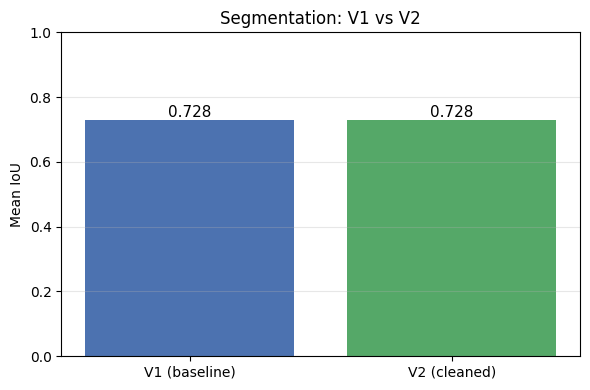

Saved segmentation_metrics.png


In [23]:
# Таблица метрик
df_seg = pd.DataFrame([{'variant': 'V1', **metrics_v1}, {'variant': 'V2', **metrics_v2}])
print(df_seg.to_string(index=False))

# Bar plot: mean_iou V1 vs V2
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['V1 (baseline)', 'V2 (cleaned)'],
       [metrics_v1['mean_iou'], metrics_v2['mean_iou']],
       color=['#4c72b0', '#55a868'])
ax.set_ylabel('Mean IoU')
ax.set_title('Segmentation: V1 vs V2')
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate([metrics_v1['mean_iou'], metrics_v2['mean_iou']]):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'segmentation_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved segmentation_metrics.png')

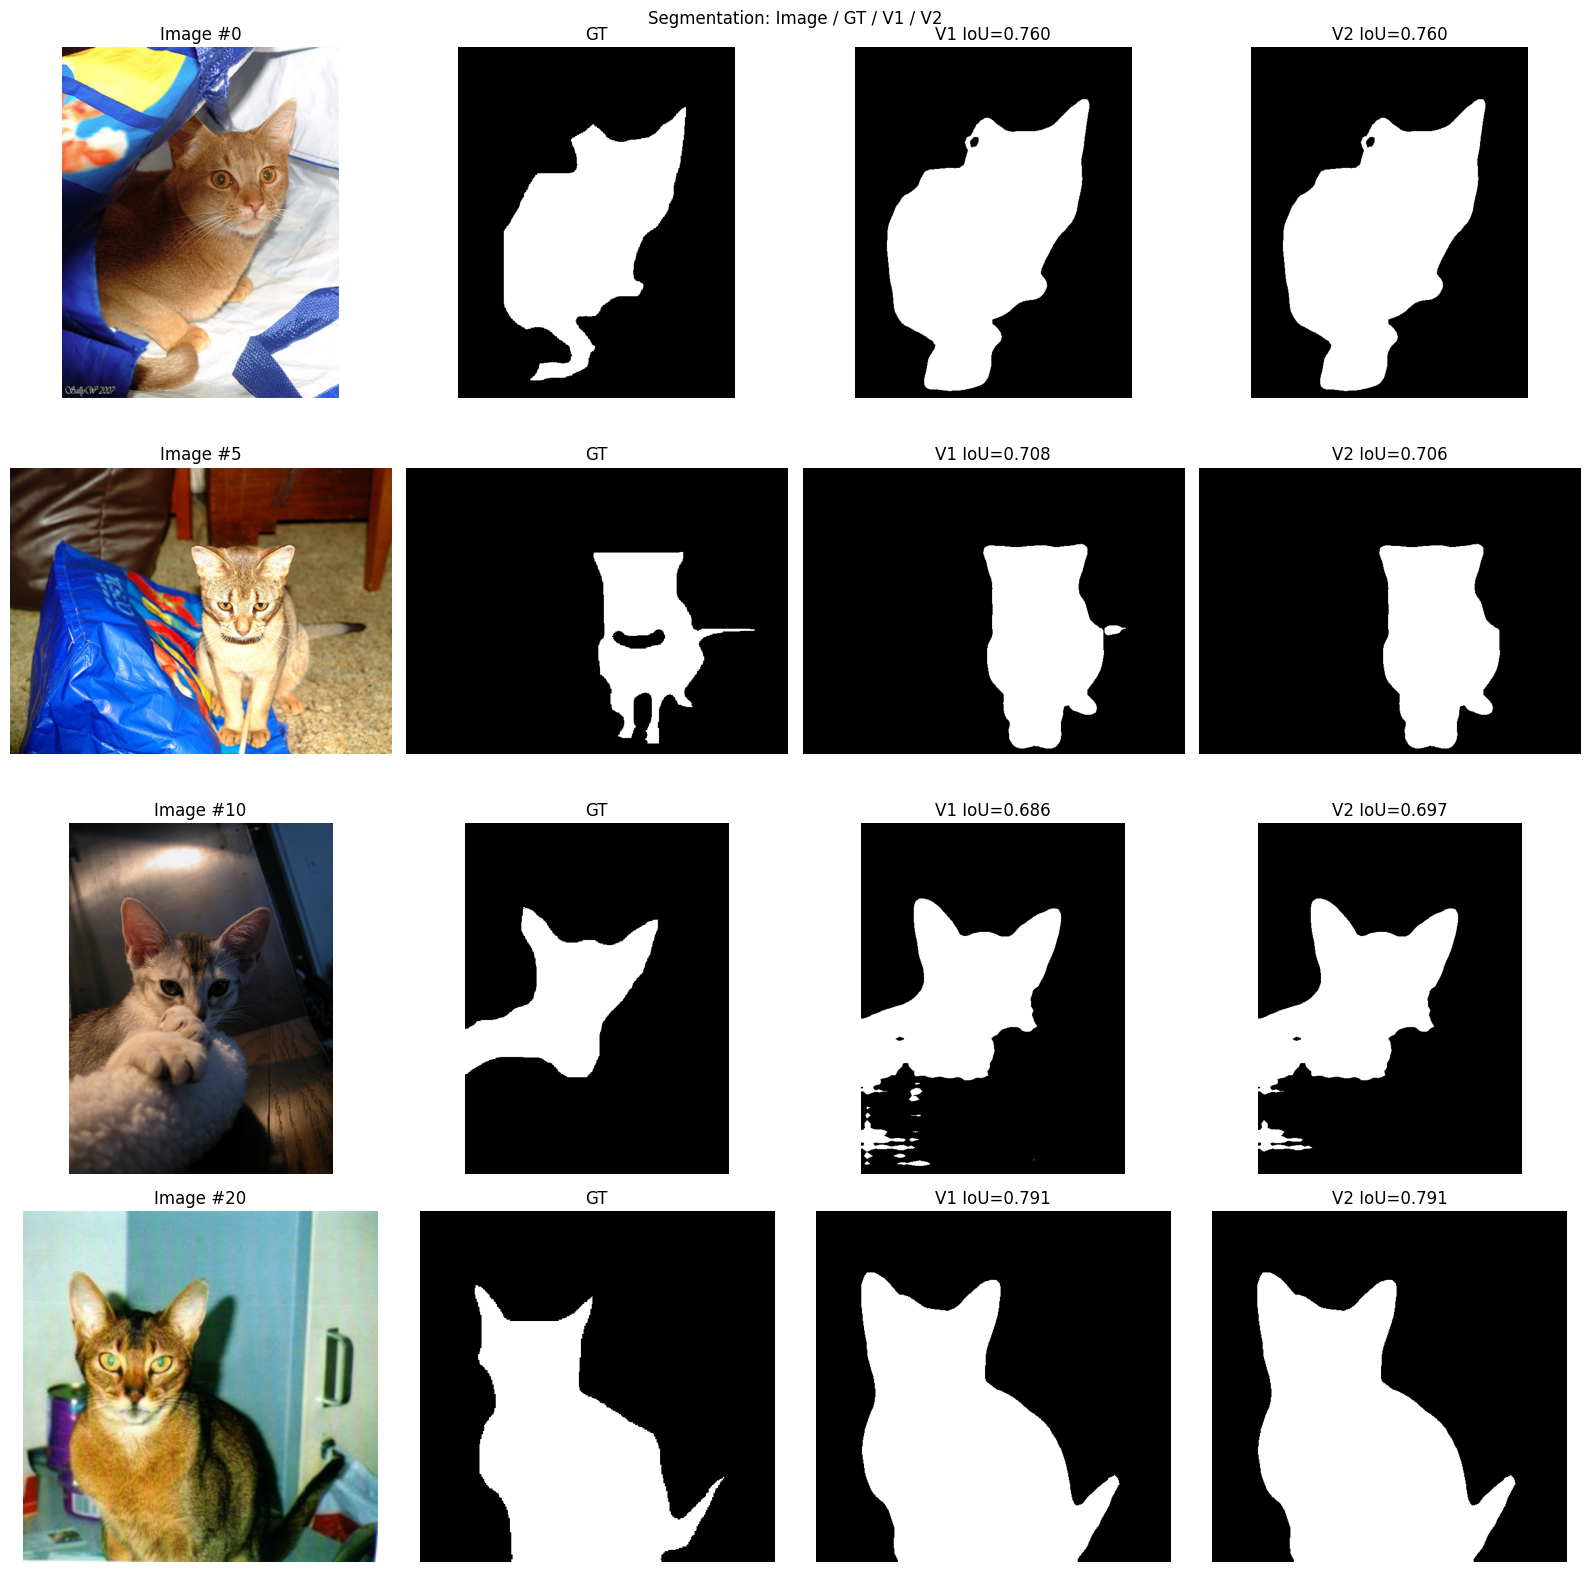

Saved segmentation_examples.png


In [24]:
# Визуализация: image / GT / V1 / V2 для нескольких примеров
vis_indices = [0, 5, 10, 20]
fig, axes = plt.subplots(len(vis_indices), 4, figsize=(16, 4 * len(vis_indices)))

for row, idx in enumerate(vis_indices):
    img_pil, trimap_pil = ds_pet[idx]
    pred_mask, model_hw = predict_pet_mask(img_pil)
    gt_mask = get_gt_mask(trimap_pil, model_hw)
    mask_v1 = postprocess_v1(pred_mask)
    mask_v2 = postprocess_v2(pred_mask)

    iou1 = compute_seg_metrics(mask_v1, gt_mask)['iou']
    iou2 = compute_seg_metrics(mask_v2, gt_mask)['iou']

    # Resize image for display
    img_rs = TF.resize(img_pil, list(model_hw))

    axes[row, 0].imshow(img_rs); axes[row, 0].set_title(f'Image #{idx}'); axes[row, 0].axis('off')
    axes[row, 1].imshow(gt_mask.numpy(), cmap='gray'); axes[row, 1].set_title('GT'); axes[row, 1].axis('off')
    axes[row, 2].imshow(mask_v1.numpy(), cmap='gray'); axes[row, 2].set_title(f'V1 IoU={iou1:.3f}'); axes[row, 2].axis('off')
    axes[row, 3].imshow(mask_v2.numpy(), cmap='gray'); axes[row, 3].set_title(f'V2 IoU={iou2:.3f}'); axes[row, 3].axis('off')

plt.suptitle('Segmentation: Image / GT / V1 / V2', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'segmentation_examples.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved segmentation_examples.png')

---
## Финал: артефакты

In [ ]:
# Собираем runs.csv с полями по требованиям
rows = []
for exp_id in ['C1', 'C2', 'C3', 'C4']:
    r = all_results[exp_id]
    lr_str = '1e-4/1e-3' if exp_id == 'C4' else '1e-3'
    notes = {
        'C1': 'без аугментаций',
        'C2': 'с аугментациями (HFlip + RandomCrop + ColorJitter)',
        'C3': 'backbone заморожен',
        'C4': 'backbone lr=1e-4 head lr=1e-3; weight_decay=1e-4',
    }
    rows.append({
        'experiment_id': exp_id,
        'task': 'classification',
        'dataset': 'STL10',
        'seed': RANDOM_STATE,
        'model_summary': f'{r["name"]} ({r["params"]} trainable params)',
        'optimizer': 'Adam',
        'lr': lr_str,
        'epochs_trained': EPOCHS_CNN if exp_id in ('C1', 'C2') else EPOCHS_RN,
        'best_val_accuracy': round(r['best_val_acc'], 4),
        'test_accuracy': round(r.get('test_acc', float('nan')), 4),
        'precision': '',
        'recall': '',
        'mean_iou': '',
        'notes': notes[exp_id],
    })

for variant, metrics in [('V1', metrics_v1), ('V2', metrics_v2)]:
    notes_seg = 'базовая постобработка (argmax)' if variant == 'V1' else 'удаление малых связных компонент (< 500 px)'
    rows.append({
        'experiment_id': variant,
        'task': 'segmentation',
        'dataset': 'OxfordIIITPet',
        'seed': RANDOM_STATE,
        'model_summary': 'DeepLabV3_ResNet50 (COCO_WITH_VOC_LABELS_V1; inference only)',
        'optimizer': '—',
        'lr': '—',
        'epochs_trained': 0,
        'best_val_accuracy': '',
        'test_accuracy': '',
        'precision': round(metrics['pixel_precision'], 4),
        'recall': round(metrics['pixel_recall'], 4),
        'mean_iou': round(metrics['mean_iou'], 4),
        'notes': notes_seg,
    })

df_runs = pd.DataFrame(rows)
df_runs.to_csv(os.path.join(ARTIFACTS_DIR, 'runs.csv'), index=False)
print(df_runs.to_string(index=False))
print(f'\nSaved runs.csv')

In [26]:
print('=' * 60)
print('ИТОГИ')
print('=' * 60)
print(f'\nЧасть A: Классификация (STL10)')
for eid in ['C1', 'C2', 'C3', 'C4']:
    r = all_results[eid]
    t = f', test={r["test_acc"]:.4f}' if 'test_acc' in r else ''
    print(f'  {eid} ({r["name"]}): val={r["best_val_acc"]:.4f}{t}')
print(f'  Лучший: {best_exp}, test_accuracy={test_acc:.4f}')

print(f'\nЧасть B: Сегментация (OxfordIIITPet)')
print(f'  V1: mean_iou={metrics_v1["mean_iou"]:.4f}, '
      f'precision={metrics_v1["pixel_precision"]:.4f}, '
      f'recall={metrics_v1["pixel_recall"]:.4f}')
print(f'  V2: mean_iou={metrics_v2["mean_iou"]:.4f}, '
      f'precision={metrics_v2["pixel_precision"]:.4f}, '
      f'recall={metrics_v2["pixel_recall"]:.4f}')

print(f'\nАртефакты:')
for f in os.listdir(ARTIFACTS_DIR):
    full = os.path.join(ARTIFACTS_DIR, f)
    if os.path.isdir(full):
        for ff in os.listdir(full):
            print(f'  {os.path.join(f, ff)}')
    else:
        print(f'  {f}')
print('\nDone!')

ИТОГИ

Часть A: Классификация (STL10)
  C1 (simple-cnn-base): val=0.5980
  C2 (simple-cnn-aug): val=0.6130
  C3 (resnet18-head-only): val=0.9420
  C4 (resnet18-finetune): val=0.9480, test=0.9449
  Лучший: C4, test_accuracy=0.9449

Часть B: Сегментация (OxfordIIITPet)
  V1: mean_iou=0.7279, precision=0.7355, recall=0.9880
  V2: mean_iou=0.7281, precision=0.7357, recall=0.9880

Артефакты:
  runs.csv
  best_classifier_config.json
  figures/segmentation_examples.png
  figures/classification_curves_best.png
  figures/segmentation_metrics.png
  figures/classification_compare.png
  figures/augmentations_preview.png
  best_classifier.pt

Done!
